In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\Public\Documents\Axel\wcup26\matchStats\csv\fotmob_match_stats.csv')
df

,matchId,matchRound,homeTeamName,homeTeamid,awayTeamName,awayTeamid,home_goals,away_goals,ball_possession_home,ball_possession_away,...,ground_duels_won_home,ground_duels_won_away,aerial_won_home,aerial_won_away,dribbles_succeeded_home,dribbles_succeeded_away,yellow_cards_home,yellow_cards_away,red_cards_home,red_cards_away
0,4667751,1,Mexico,6710,South Africa,6316,2,0,60,40,...,32 (55%),26 (45%),15 (68%),7 (32%),9 (60%),1 (17%),1,2,1,2
1,4667752,1,South Korea,7804,Czechia,8496,2,1,62,38,...,29 (57%),22 (43%),27 (63%),16 (37%),8 (57%),4 (57%),1,0,0,0
2,4667757,1,Canada,5810,Bosnia and Herzegovina,10106,1,1,61,39,...,50 (58%),36 (42%),20 (32%),43 (68%),7 (47%),5 (23%),2,3,0,0
3,4667771,1,USA,6713,Paraguay,6724,4,1,65,35,...,47 (55%),39 (45%),18 (53%),16 (47%),22 (63%),6 (60%),1,5,0,0
4,4667758,1,Qatar,5902,Switzerland,6717,1,1,32,68,...,26 (49%),27 (51%),10 (50%),10 (50%),2 (50%),7 (54%),2,1,0,0
5,4667764,1,Brazil,8256,Morocco,6262,1,1,51,49,...,41 (41%),58 (59%),12 (75%),4 (25%),5 (19%),16 (55%),2,0,0,0
6,4667765,1,Haiti,5934,Scotland,8498,0,1,54,46,...,38 (50%),38 (50%),13 (38%),21 (62%),6 (43%),5 (38%),1,3,0,0
7,4667772,1,Australia,6716,Turkiye,6595,2,0,28,72,...,27 (48%),29 (52%),15 (47%),17 (53%),8 (73%),5 (36%),0,1,0,0
8,4667777,1,Germany,8570,Curacao,287981,7,1,65,35,...,38 (46%),45 (54%),9 (64%),5 (36%),9 (50%),12 (57%),0,0,0,0
9,4667783,1,Netherlands,6708,Japan,6715,2,2,60,40,...,25 (54%),21 (46%),21 (75%),7 (25%),8 (53%),3 (33%),3,0,0,0


In [10]:
df.columns

Index(['matchId', 'matchRound', 'homeTeamName', 'homeTeamid', 'awayTeamName',
       'awayTeamid', 'home_goals', 'away_goals', 'ball_possession_home',
       'ball_possession_away', 'big_chances_home', 'big_chances_away',
       'big_chances_missed_home', 'big_chances_missed_away', 'fouls_home',
       'fouls_away', 'corners_home', 'corners_away', 'total_shots_home',
       'total_shots_away', 'shots_off_target_home', 'shots_off_target_away',
       'shots_on_target_home', 'shots_on_target_away', 'blocked_shots_home',
       'blocked_shots_away', 'hit_woodwork_home', 'hit_woodwork_away',
       'shots_inside_box_home', 'shots_inside_box_away',
       'shots_outside_box_home', 'shots_outside_box_away', 'xG_home',
       'xG_away', 'xG_open_play_home', 'xG_open_play_away', 'xG_set_play_home',
       'xG_set_play_away', 'xG_non_penalty_home', 'xG_non_penalty_away',
       'xGOT_home', 'xGOT_away', 'passes_home', 'passes_away',
       'accurate_passes_home', 'accurate_passes_away', 'own_ha

In [3]:
# p90 minutes MEAN

# xG_home, xG_open_play_home, xG_set_play_home, xG_non_penalty_home, xGOT_home

# Create a dataframe with home teams data
xG_mean_home_df = df[['homeTeamName', 'homeTeamid', 'xG_home', 'xG_open_play_home', 'xG_set_play_home', 'xG_non_penalty_home', 'xGOT_home']].rename(
    columns={
        'homeTeamName': 'teamName',
        'homeTeamid': 'teamId',
        'xG_home': 'xG',
        'xG_open_play_home': 'xG_open_play',
        'xG_set_play_home': 'xG_set_play',
        'xG_non_penalty_home': 'xG_non_penalty',
        'xGOT_home': 'xGOT'
    }
)

# Create a dataframe with away teams data
xG_mean_away_df = df[['awayTeamName', 'awayTeamid', 'xG_away', 'xG_open_play_away', 'xG_set_play_away', 'xG_non_penalty_away', 'xGOT_away']].rename(
    columns={
        'awayTeamName': 'teamName',
        'awayTeamid': 'teamId',
        'xG_away': 'xG',
        'xG_open_play_away': 'xG_open_play',
        'xG_set_play_away': 'xG_set_play',
        'xG_non_penalty_away': 'xG_non_penalty',
        'xGOT_away': 'xGOT'
    }
)

# Stack both dataframes together
xG_mean_possession = pd.concat([xG_mean_home_df, xG_mean_away_df], ignore_index=True)

xG_mean_df = (
    xG_mean_possession
    .groupby(['teamId', 'teamName']).agg(
          matches=('teamName', 'size'),
          avg_xG=('xG', 'mean'),
          total_xG=('xG', 'sum'),
          avg_xG_open_play=('xG_open_play', 'mean'),
          avg_xG_set_play=('xG_set_play', 'mean'),
          avg_xG_non_penalty=('xG_non_penalty', 'mean')
      )
      .sort_values('avg_xG', ascending=False)
      .reset_index()
)

xG_mean_df

,teamId,teamName,matches,avg_xG,total_xG,avg_xG_open_play,avg_xG_set_play,avg_xG_non_penalty
0,8570,Germany,1,4.220,4.22,2.990,0.440,3.430
1,8491,England,1,3.200,3.20,1.380,1.030,2.410
2,5810,Canada,2,2.925,5.85,2.380,0.540,2.925
3,6717,Switzerland,2,2.630,5.26,1.375,0.465,1.840
4,8492,Norway,1,2.520,2.52,1.990,0.530,2.520
5,6720,Spain,1,2.100,2.10,1.670,0.430,2.100
6,6723,France,1,1.890,1.89,1.890,1.890,2.000
7,5796,Uruguay,1,1.720,1.72,0.850,0.880,1.720
8,8255,Austria,1,1.690,1.69,0.890,0.010,0.900
9,8258,Colombia,1,1.610,1.61,1.390,0.220,1.610


In [4]:
# MEAN

# ball_possession_home

# Create a dataframe with home teams data
mean_home_df = df[['homeTeamName', 'homeTeamid', 'ball_possession_home']].rename(
    columns={
        'homeTeamName': 'teamName',
        'homeTeamid': 'teamId',
        'ball_possession_home': 'ball_possession'
    }
)

# Create a dataframe with away teams data
mean_away_df = df[['awayTeamName', 'awayTeamid', 'ball_possession_away']].rename(
    columns={
        'awayTeamName': 'teamName',
        'awayTeamid': 'teamId',
        'ball_possession_away': 'ball_possession'
    }
)

# Stack both dataframes together
mean_possession = pd.concat([mean_home_df, mean_away_df], ignore_index=True)

# Mean
ball_possession_df = (
    mean_possession
    .groupby(['teamId', 'teamName'], as_index=False)[['ball_possession']]
    .mean()
    .rename(columns={'ball_possession': 'mean_ball_possession'})
    .sort_values('mean_ball_possession', ascending=False)
)

ball_possession_df

,teamId,teamName,mean_ball_possession
36,8361,Portugal,75.0
27,6720,Spain,74.0
14,6595,Turkiye,72.0
1,5810,Canada,70.0
0,5796,Uruguay,67.0
25,6717,Switzerland,65.0
21,6713,USA,65.0
42,8570,Germany,65.0
32,8255,Austria,63.0
7,5922,Panama,62.0


In [5]:
# Columns to SUM

# home_goals, big_chances_home, big_chances_missed_home, corners_home, total_shots_home, shots_off_target_home, blocked_shots_home, hit_woodwork_home, shots_inside_box_home, shots_outside_box_home,
# passes_home, own_half_passes_home, opposition_half_passes_home, throws_home, touches_opp_box_home, offsides_home, tackles_won_home, interceptions_home, blocks_home, clearances_home, keeper_saves_home,
# duel_won_home, yellow_cards_home, red_cards_home

# Create a dataframe with home teams data
home_df = df[['homeTeamName', 'homeTeamid', 'home_goals', 'big_chances_home', 'big_chances_missed_home', 'corners_home', 'total_shots_home', 'shots_off_target_home', 'blocked_shots_home',
              'hit_woodwork_home', 'shots_inside_box_home', 'shots_outside_box_home', 'passes_home', 'own_half_passes_home', 'opposition_half_passes_home', 'throws_home', 'touches_opp_box_home',
              'offsides_home', 'tackles_won_home', 'interceptions_home', 'blocks_home', 'clearances_home', 'keeper_saves_home', 'duel_won_home', 'yellow_cards_home', 'red_cards_home']].rename(
    columns={
        'homeTeamName': 'teamName',
        'homeTeamid': 'teamId',
        'home_goals': 'goals',
        'big_chances_home': 'big_chances',
        'big_chances_missed_home': 'big_chances_missed',
        'corners_home': 'corners',
        'total_shots_home': 'total_shots',
        'shots_off_target_home': 'shots_off_target',
        'blocked_shots_home': 'blocked_shots',
        'hit_woodwork_home': 'hit_woodwork',
        'shots_inside_box_home': 'shots_inside_box',
        'shots_outside_box_home': 'shots_outside_box',
        'passes_home': 'passes',
        'own_half_passes_home': 'own_half_passes',
        'opposition_half_passes_home': 'opposition_half_passes',
        'throws_home': 'throws',
        'touches_opp_box_home': 'touches_opp_box',
        'offsides_home': 'offsides',
        'tackles_won_home': 'tackles_won',
        'interceptions_home': 'interceptions',
        'blocks_home': 'blocks',
        'clearances_home': 'clearances',
        'keeper_saves_home': 'keeper_saves',
        'duel_won_home': 'duel_won',
        'yellow_cards_home': 'yellow_cards',
        'red_cards_home': 'red_cards'
    }
)

# Create a dataframe with away teams data
away_df = df[['awayTeamName', 'awayTeamid', 'away_goals', 'big_chances_away', 'big_chances_missed_away', 'corners_away', 'total_shots_away', 'shots_off_target_away', 'blocked_shots_away',
              'hit_woodwork_away', 'shots_inside_box_away', 'shots_outside_box_away', 'passes_away', 'own_half_passes_away', 'opposition_half_passes_away', 'throws_away', 'touches_opp_box_away',
              'offsides_away', 'tackles_won_away', 'interceptions_away', 'blocks_away', 'clearances_away', 'keeper_saves_away', 'duel_won_away', 'yellow_cards_away', 'red_cards_away']].rename(
    columns={
        'awayTeamName': 'teamName',
        'awayTeamid': 'teamId',
        'away_goals': 'goals',
        'big_chances_away': 'big_chances',
        'big_chances_missed_away': 'big_chances_missed',
        'corners_away': 'corners',
        'total_shots_away': 'total_shots',
        'shots_off_target_away': 'shots_off_target',
        'blocked_shots_away': 'blocked_shots',
        'hit_woodwork_away': 'hit_woodwork',
        'shots_inside_box_away': 'shots_inside_box',
        'shots_outside_box_away': 'shots_outside_box',
        'passes_away': 'passes',
        'own_half_passes_away': 'own_half_passes',
        'opposition_half_passes_away': 'opposition_half_passes',
        'throws_away': 'throws',
        'touches_opp_box_away': 'touches_opp_box',
        'offsides_away': 'offsides',
        'tackles_won_away': 'tackles_won',
        'interceptions_away': 'interceptions',
        'blocks_away': 'blocks',
        'clearances_away': 'clearances',
        'keeper_saves_away': 'keeper_saves',
        'duel_won_away': 'duel_won',
        'yellow_cards_away': 'yellow_cards',
        'red_cards_away': 'red_cards'
    }
)

# Stack both dataframes together
teams_goals = pd.concat([home_df, away_df], ignore_index=True)

# Sum
sum_df = (
    teams_goals
    .groupby(['teamId', 'teamName'], as_index=False)[['goals', 'big_chances', 'big_chances_missed', 'corners', 'total_shots', 'shots_off_target', 'blocked_shots', 'hit_woodwork', 'shots_inside_box',
                                                      'shots_outside_box', 'passes', 'own_half_passes', 'opposition_half_passes', 'throws', 'touches_opp_box', 'offsides', 'tackles_won', 'interceptions',
                                                      'blocks', 'clearances', 'keeper_saves', 'duel_won', 'yellow_cards', 'red_cards']]
    .sum()
    .sort_values('goals', ascending=False)
)

sum_df

,teamId,teamName,goals,big_chances,big_chances_missed,corners,total_shots,shots_off_target,blocked_shots,hit_woodwork,...,touches_opp_box,offsides,tackles_won,interceptions,blocks,clearances,keeper_saves,duel_won,yellow_cards,red_cards
1,5810,Canada,7,135,8,3.0,45,13,18,1,...,135,2,32,10,1,24,2,103,3,0
42,8570,Germany,7,63,6,0.0,26,6,8,1,...,63,0,19,12,0,8,1,47,0,0
25,6717,Switzerland,5,77,10,2.0,39,13,12,0,...,77,4,27,12,1,30,5,89,2,0
41,8520,Sweden,5,22,4,0.0,13,3,3,0,...,22,3,14,6,1,23,1,41,0,0
21,6713,USA,4,53,4,1.0,16,6,4,0,...,53,2,9,9,3,15,0,65,1,0
37,8491,England,4,37,7,0.0,22,6,5,0,...,37,0,9,7,2,16,3,40,0,0
38,8492,Norway,4,25,5,0.0,12,4,3,0,...,25,0,15,2,2,22,0,48,0,0
15,6706,Argentina,3,12,1,0.0,10,4,0,0,...,12,3,27,10,3,17,0,39,0,0
19,6710,Mexico,3,26,4,1.0,24,10,6,1,...,26,4,26,14,3,35,4,89,1,1
28,6723,France,3,19,4,0.0,11,1,2,0,...,19,1,18,8,1,14,2,43,0,0


In [6]:
# clean columns 467 (90%)
# fouls_home, accurate_passes_home, accurate_long_passes_home, accurate_crosses_home, ground_duels_won_home, aerial_won_home, dribbles_succeeded_home

df_to_clean = df[['homeTeamid', 'homeTeamName', 'awayTeamid', 'awayTeamName', 'fouls_home', 'fouls_away', 'accurate_passes_home', 'accurate_passes_away', 'accurate_long_passes_home', 'accurate_long_passes_away', 'accurate_crosses_home', 'accurate_crosses_away',
                       'ground_duels_won_home', 'ground_duels_won_away', 'aerial_won_home', 'aerial_won_away', 'dribbles_succeeded_home', 'dribbles_succeeded_away']]

df_to_clean

,homeTeamid,homeTeamName,awayTeamid,awayTeamName,fouls_home,fouls_away,accurate_passes_home,accurate_passes_away,accurate_long_passes_home,accurate_long_passes_away,accurate_crosses_home,accurate_crosses_away,ground_duels_won_home,ground_duels_won_away,aerial_won_home,aerial_won_away,dribbles_succeeded_home,dribbles_succeeded_away
0,6710,Mexico,6316,South Africa,467 (90%),272 (81%),467 (90%),272 (81%),31 (65%),17 (37%),4 (33%),1 (13%),32 (55%),26 (45%),15 (68%),7 (32%),9 (60%),1 (17%)
1,7804,South Korea,8496,Czechia,469 (87%),230 (70%),469 (87%),230 (70%),30 (49%),23 (33%),3 (25%),3 (20%),29 (57%),22 (43%),27 (63%),16 (37%),8 (57%),4 (57%)
2,5810,Canada,10106,Bosnia and Herzegovina,310 (74%),170 (63%),310 (74%),170 (63%),19 (44%),18 (29%),5 (21%),6 (60%),50 (58%),36 (42%),20 (32%),43 (68%),7 (47%),5 (23%)
3,6713,USA,6724,Paraguay,509 (85%),232 (73%),509 (85%),232 (73%),26 (54%),20 (34%),3 (16%),0 (0%),47 (55%),39 (45%),18 (53%),16 (47%),22 (63%),6 (60%)
4,5902,Qatar,6717,Switzerland,200 (72%),527 (91%),200 (72%),527 (91%),19 (30%),27 (77%),1 (11%),6 (17%),26 (49%),27 (51%),10 (50%),10 (50%),2 (50%),7 (54%)
5,8256,Brazil,6262,Morocco,449 (87%),419 (86%),449 (87%),419 (86%),18 (50%),17 (33%),4 (25%),2 (13%),41 (41%),58 (59%),12 (75%),4 (25%),5 (19%),16 (55%)
6,5934,Haiti,8498,Scotland,367 (85%),307 (82%),367 (85%),307 (82%),26 (44%),30 (52%),5 (22%),5 (36%),38 (50%),38 (50%),13 (38%),21 (62%),6 (43%),5 (38%)
7,6716,Australia,6595,Turkiye,201 (74%),635 (90%),201 (74%),635 (90%),16 (28%),19 (68%),4 (29%),2 (8%),27 (48%),29 (52%),15 (47%),17 (53%),8 (73%),5 (36%)
8,8570,Germany,287981,Curacao,554 (87%),282 (82%),554 (87%),282 (82%),12 (48%),17 (39%),5 (42%),2 (29%),38 (46%),45 (54%),9 (64%),5 (36%),9 (50%),12 (57%)
9,6708,Netherlands,6715,Japan,463 (88%),286 (84%),463 (88%),286 (84%),16 (46%),13 (36%),8 (38%),6 (26%),25 (54%),21 (46%),21 (75%),7 (25%),8 (53%),3 (33%)


In [26]:
# ✖️✖️✖️
# clean (%) with regex
# 👇 fixed code

cleaned_df = pd.DataFrame()

cleaned_df['fouls_home'] = df_to_clean['fouls_home'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['fouls_away'] = df_to_clean['fouls_away'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['accurate_passes_home'] = df_to_clean['accurate_passes_home'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['accurate_passes_away'] = df_to_clean['accurate_passes_away'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['accurate_long_passes_home'] = df_to_clean['accurate_long_passes_home'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['accurate_long_passes_away'] = df_to_clean['accurate_long_passes_away'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['accurate_crosses_home'] = df_to_clean['accurate_crosses_home'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['accurate_crosses_away'] = df_to_clean['accurate_crosses_away'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['ground_duels_won_home'] = df_to_clean['ground_duels_won_home'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['ground_duels_won_away'] = df_to_clean['ground_duels_won_away'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['aerial_won_home'] = df_to_clean['aerial_won_home'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['aerial_won_away'] = df_to_clean['aerial_won_away'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['dribbles_succeeded_home'] = df_to_clean['dribbles_succeeded_home'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)
cleaned_df['dribbles_succeeded_away'] = df_to_clean['dribbles_succeeded_away'].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)

cleaned_df

,fouls_home,fouls_away,accurate_passes_home,accurate_passes_away,accurate_long_passes_home,accurate_long_passes_away,accurate_crosses_home,accurate_crosses_away,ground_duels_won_home,ground_duels_won_away,aerial_won_home,aerial_won_away,dribbles_succeeded_home,dribbles_succeeded_away
0,467,272,467,272,31,17,4,1,32,26,15,7,9,1
1,469,230,469,230,30,23,3,3,29,22,27,16,8,4
2,310,170,310,170,19,18,5,6,50,36,20,43,7,5
3,509,232,509,232,26,20,3,0,47,39,18,16,22,6
4,200,527,200,527,19,27,1,6,26,27,10,10,2,7
5,449,419,449,419,18,17,4,2,41,58,12,4,5,16
6,367,307,367,307,26,30,5,5,38,38,13,21,6,5
7,201,635,201,635,16,19,4,2,27,29,15,17,8,5
8,554,282,554,282,12,17,5,2,38,45,9,5,9,12
9,463,286,463,286,16,13,8,6,25,21,21,7,8,3


In [27]:
# ✖️✖️✖️
# clean (%) with regex
# loop with a mapping dictionary

columns_to_clean = [
    'fouls', 'accurate_passes', 'accurate_long_passes', 
    'accurate_crosses', 'ground_duels_won', 'aerial_won', 
    'dribbles_succeeded'
]

cleaned_df = pd.DataFrame()

for col in columns_to_clean:
    for suffix in ['home', 'away']:
        original_col = f'{col}_{suffix}'
        cleaned_df[original_col] = df_to_clean[original_col].str.replace(r'\s*\(.*\)', '', regex=True).astype(int)

cleaned_df

,fouls_home,fouls_away,accurate_passes_home,accurate_passes_away,accurate_long_passes_home,accurate_long_passes_away,accurate_crosses_home,accurate_crosses_away,ground_duels_won_home,ground_duels_won_away,aerial_won_home,aerial_won_away,dribbles_succeeded_home,dribbles_succeeded_away
0,467,272,467,272,31,17,4,1,32,26,15,7,9,1
1,469,230,469,230,30,23,3,3,29,22,27,16,8,4
2,310,170,310,170,19,18,5,6,50,36,20,43,7,5
3,509,232,509,232,26,20,3,0,47,39,18,16,22,6
4,200,527,200,527,19,27,1,6,26,27,10,10,2,7
5,449,419,449,419,18,17,4,2,41,58,12,4,5,16
6,367,307,367,307,26,30,5,5,38,38,13,21,6,5
7,201,635,201,635,16,19,4,2,27,29,15,17,8,5
8,554,282,554,282,12,17,5,2,38,45,9,5,9,12
9,463,286,463,286,16,13,8,6,25,21,21,7,8,3


In [7]:
# ✔️✔️✔️ FINAL code for cleaning df

columns_to_clean = [
    'fouls', 'accurate_passes', 'accurate_long_passes', 
    'accurate_crosses', 'ground_duels_won', 'aerial_won', 
    'dribbles_succeeded'
]

cleaned_df = df_to_clean.copy()

for col in columns_to_clean:
    for suffix in ['home', 'away']:
        original_col = f'{col}_{suffix}'
        cleaned_df[original_col] = (
            cleaned_df[original_col]
            .str.replace(r'\s*\(.*\)', '', regex=True)
            .astype(int)
        )

cleaned_df

,homeTeamid,homeTeamName,awayTeamid,awayTeamName,fouls_home,fouls_away,accurate_passes_home,accurate_passes_away,accurate_long_passes_home,accurate_long_passes_away,accurate_crosses_home,accurate_crosses_away,ground_duels_won_home,ground_duels_won_away,aerial_won_home,aerial_won_away,dribbles_succeeded_home,dribbles_succeeded_away
0,6710,Mexico,6316,South Africa,467,272,467,272,31,17,4,1,32,26,15,7,9,1
1,7804,South Korea,8496,Czechia,469,230,469,230,30,23,3,3,29,22,27,16,8,4
2,5810,Canada,10106,Bosnia and Herzegovina,310,170,310,170,19,18,5,6,50,36,20,43,7,5
3,6713,USA,6724,Paraguay,509,232,509,232,26,20,3,0,47,39,18,16,22,6
4,5902,Qatar,6717,Switzerland,200,527,200,527,19,27,1,6,26,27,10,10,2,7
5,8256,Brazil,6262,Morocco,449,419,449,419,18,17,4,2,41,58,12,4,5,16
6,5934,Haiti,8498,Scotland,367,307,367,307,26,30,5,5,38,38,13,21,6,5
7,6716,Australia,6595,Turkiye,201,635,201,635,16,19,4,2,27,29,15,17,8,5
8,8570,Germany,287981,Curacao,554,282,554,282,12,17,5,2,38,45,9,5,9,12
9,6708,Netherlands,6715,Japan,463,286,463,286,16,13,8,6,25,21,21,7,8,3


In [8]:
# SUM succeeded data
# fouls_home, accurate_passes_home, accurate_long_passes_home, accurate_crosses_home, ground_duels_won_home, aerial_won_home, dribbles_succeeded_home

# Create a dataframe with home teams data
succeed_home_df = cleaned_df[['homeTeamName', 'homeTeamid', 'fouls_home', 'accurate_passes_home', 'accurate_long_passes_home', 'accurate_crosses_home', 'ground_duels_won_home',
                      'aerial_won_home', 'dribbles_succeeded_home']].rename(
    columns={
        'homeTeamName': 'teamName',
        'homeTeamid': 'teamId',
        'fouls_home': 'fouls',
        'accurate_passes_home': 'accurate_passes',
        'accurate_long_passes_home': 'accurate_long_passes',
        'accurate_crosses_home': 'accurate_crosses',
        'ground_duels_won_home': 'ground_duels_won',
        'aerial_won_home': 'aerial_won',
        'dribbles_succeeded_home': 'dribbles_succeeded'        
    }
)

# Create a dataframe with away teams data
succeed_away_df = cleaned_df[['awayTeamName', 'awayTeamid', 'fouls_away', 'accurate_passes_away', 'accurate_long_passes_away', 'accurate_crosses_away', 'ground_duels_won_away',
                      'aerial_won_away', 'dribbles_succeeded_away']].rename(
    columns={
        'awayTeamName': 'teamName',
        'awayTeamid': 'teamId',
        'fouls_away': 'fouls',
        'accurate_passes_away': 'accurate_passes',
        'accurate_long_passes_away': 'accurate_long_passes',
        'accurate_crosses_away': 'accurate_crosses',
        'ground_duels_won_away': 'ground_duels_won',
        'aerial_won_away': 'aerial_won',
        'dribbles_succeeded_away': 'dribbles_succeeded'
    }
)

# Stack both dataframes together
succeed_sum_df = pd.concat([succeed_home_df, succeed_away_df], ignore_index=True)

succeed_df = (
    succeed_sum_df
    .groupby(['teamId', 'teamName'], as_index=False)[['fouls', 'accurate_passes', 'accurate_long_passes', 'accurate_crosses', 'ground_duels_won', 'aerial_won',
                                                      'dribbles_succeeded']]
    .sum()
    .sort_values('accurate_passes', ascending=False)
)

succeed_df

,teamId,teamName,fouls,accurate_passes,accurate_long_passes,accurate_crosses,ground_duels_won,aerial_won,dribbles_succeeded
25,6717,Switzerland,1043,1043,52,7,69,20,13
31,7804,South Korea,957,957,53,8,63,40,17
1,5810,Canada,825,825,29,18,75,28,13
19,6710,Mexico,816,816,47,8,59,30,15
10,6316,South Africa,780,780,47,5,64,16,9
27,6720,Spain,734,734,24,6,21,19,7
36,8361,Portugal,724,724,41,6,25,9,5
14,6595,Turkiye,635,635,19,2,29,17,5
11,6317,Algeria,563,563,15,1,38,5,8
42,8570,Germany,554,554,12,5,38,9,9


In [9]:
# JOIN sum_df & succeed_df

final_df = pd.merge(
    succeed_df,
    sum_df,
    on=['teamId', 'teamName'],
    how='inner'  # keeps only matching teamIds
)

final_df.head()

,teamId,teamName,fouls,accurate_passes,accurate_long_passes,accurate_crosses,ground_duels_won,aerial_won,dribbles_succeeded,goals,...,touches_opp_box,offsides,tackles_won,interceptions,blocks,clearances,keeper_saves,duel_won,yellow_cards,red_cards
0,6717,Switzerland,1043,1043,52,7,69,20,13,5,...,77,4,27,12,1,30,5,89,2,0
1,7804,South Korea,957,957,53,8,63,40,17,2,...,35,8,24,14,1,44,6,103,3,0
2,5810,Canada,825,825,29,18,75,28,13,7,...,135,2,32,10,1,24,2,103,3,0
3,6710,Mexico,816,816,47,8,59,30,15,3,...,26,4,26,14,3,35,4,89,1,1
4,6316,South Africa,780,780,47,5,64,16,9,1,...,22,4,34,16,8,41,4,80,4,2


In [13]:
# JOIN the 4 data frames

join_df = (
    xG_mean_df
    .merge(ball_possession_df, on=['teamId', 'teamName'], how='inner')
    .merge(final_df, on=['teamId', 'teamName'], how='inner')
)

join_df

,teamId,teamName,matches,avg_xG,total_xG,avg_xG_open_play,avg_xG_set_play,avg_xG_non_penalty,mean_ball_possession,fouls,...,touches_opp_box,offsides,tackles_won,interceptions,blocks,clearances,keeper_saves,duel_won,yellow_cards,red_cards
0,8570,Germany,1,4.220,4.22,2.990,0.440,3.430,65.0,554,...,63,0,19,12,0,8,1,47,0,0
1,8491,England,1,3.200,3.20,1.380,1.030,2.410,52.0,406,...,37,0,9,7,2,16,3,40,0,0
2,5810,Canada,2,2.925,5.85,2.380,0.540,2.925,70.0,825,...,135,2,32,10,1,24,2,103,3,0
3,6717,Switzerland,2,2.630,5.26,1.375,0.465,1.840,65.0,1043,...,77,4,27,12,1,30,5,89,2,0
4,8492,Norway,1,2.520,2.52,1.990,0.530,2.520,61.0,477,...,25,0,15,2,2,22,0,48,0,0
5,6720,Spain,1,2.100,2.10,1.670,0.430,2.100,74.0,734,...,51,2,13,6,2,7,1,40,1,0
6,6723,France,1,1.890,1.89,1.890,1.890,2.000,54.0,505,...,19,1,18,8,1,14,2,43,0,0
7,5796,Uruguay,1,1.720,1.72,0.850,0.880,1.720,67.0,540,...,41,6,3,10,1,17,2,42,0,0
8,8255,Austria,1,1.690,1.69,0.890,0.010,0.900,63.0,487,...,28,3,17,15,2,24,3,44,1,0
9,8258,Colombia,1,1.610,1.61,1.390,0.220,1.610,61.0,444,...,27,3,10,6,2,20,1,36,1,0


In [16]:
join_df.columns

Index(['teamId', 'teamName', 'matches', 'avg_xG', 'total_xG',
       'avg_xG_open_play', 'avg_xG_set_play', 'avg_xG_non_penalty',
       'mean_ball_possession', 'fouls', 'accurate_passes',
       'accurate_long_passes', 'accurate_crosses', 'ground_duels_won',
       'aerial_won', 'dribbles_succeeded', 'goals', 'big_chances',
       'big_chances_missed', 'corners', 'total_shots', 'shots_off_target',
       'blocked_shots', 'hit_woodwork', 'shots_inside_box',
       'shots_outside_box', 'passes', 'own_half_passes',
       'opposition_half_passes', 'throws', 'touches_opp_box', 'offsides',
       'tackles_won', 'interceptions', 'blocks', 'clearances', 'keeper_saves',
       'duel_won', 'yellow_cards', 'red_cards'],
      dtype='str')

In [26]:
x = join_df[['teamName', 'goals', 'avg_xG']].sort_values('goals', ascending=False)
z = x.head()

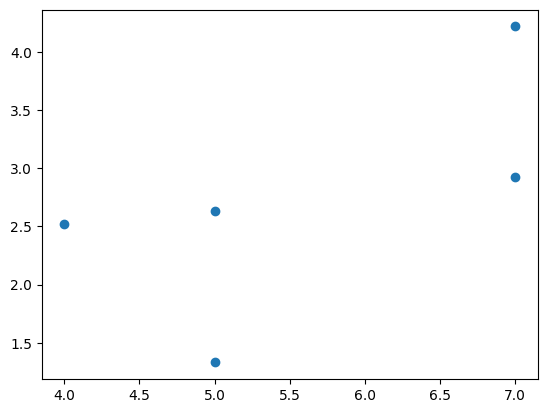

In [27]:
import matplotlib.pyplot as plt

plt.scatter(z.goals, z.avg_xG)

plt.show()

In [34]:
# Sample data
e_df = pd.DataFrame({
    'values': ['467 (90%)', '123 (45%)', '999 (100%)', '50 (5%)']
})

e_df

,values
0,467 (90%)
1,123 (45%)
2,999 (100%)
3,50 (5%)
